<a href="https://colab.research.google.com/github/PiyumalRathnayake/Treinetic_ImageClassification/blob/main/TreineticFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning Code (MobileNetV2)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications


# 1. Load and Preprocess the Data

print("Loading CIFAR-10 dataset...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values
train_images, test_images = train_images / 255.0, test_images / 255.0


# 2. Build the Model (with 96x96 upsampling)

print("Building the Transfer Learning model...")
base_model_fixed = applications.MobileNetV2(input_shape=(96, 96, 3),
                                            include_top=False,
                                            weights='imagenet')
base_model_fixed.trainable = False

transfer_model_fixed = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(96, 96), # Upsampling so MobileNet can extract features
    base_model_fixed,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

transfer_model_fixed.compile(optimizer='adam',
                             loss='sparse_categorical_crossentropy',
                             metrics=['accuracy'])


# 3. Setup Callbacks for Saving

print("Setting up automatic save checkpoints...")

checkpoint_best = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

class SaveCustomEpochs(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1

        # Save on epoch 5, 10, or exactly 12
        if current_epoch % 5 == 0 or current_epoch == 12:
            file_name = f"model_epoch_{current_epoch}.keras"
            self.model.save(file_name)
            print(f"\n[INFO] Snapshot saved as {file_name}")

my_callbacks = [checkpoint_best, SaveCustomEpochs()]




Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Building the Transfer Learning model...
Setting up automatic save checkpoints...


### Train the Model

In [ ]:
print("Training for 12 epochs...")

history = transfer_model_fixed.fit(
    train_images,
    train_labels,
    epochs=12,
    validation_data=(test_images, test_labels),
    callbacks=my_callbacks,
    verbose=1
)

Training for 12 epochs...
Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6731 - loss: 0.9462
Epoch 1: val_accuracy improved from None to 0.78700, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 355s 222ms/step - accuracy: 0.7289 - loss: 0.7782 - val_accuracy: 0.7870 - val_loss: 0.6029
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7871 - loss: 0.6129
Epoch 2: val_accuracy improved from 0.78700 to 0.79930, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 345s 221ms/step - accuracy: 0.7869 - loss: 0.6117 - val_accuracy: 0.7993 - val_loss: 0.5815
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8059 - loss: 0.5504
Epoch 3: val_accuracy improved from 0.79930 to 0.80710, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 381s 22

### Visualize the Results

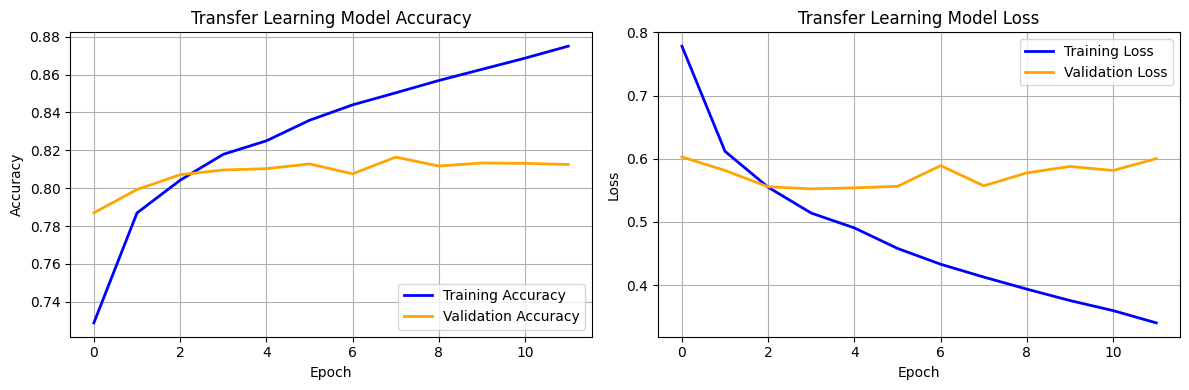


Final Test Accuracy: 0.8125
Final Test Loss: 0.6003


In [ ]:
import matplotlib.pyplot as plt


#  Visualize Accuracy and Loss

plt.figure(figsize=(12, 4))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Transfer Learning Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Transfer Learning Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Make the layout clean and show the plots
plt.tight_layout()
plt.show()

# Print the final numerical results for easy copy-pasting
final_loss, final_acc = transfer_model_fixed.evaluate(test_images, test_labels, verbose=0)
print(f"\nFinal Test Accuracy: {final_acc:.4f}")
print(f"Final Test Loss: {final_loss:.4f}")

### Testing Transfer learning method

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

# The 10 categories CIFAR-10 knows how to recognize
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Please upload an image from your computer to test:")

# 1. Create the Colab upload widget
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Load the original image just so we can display it nicely on screen
    display_img = image.load_img(filename)

    # 3. Load a 32x32 version of the image to feed into the model's input layer
    img = image.load_img(filename, target_size=(32, 32))

    # 4. Convert to numbers and normalize (divide by 255.0 just like our training data)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    # 5. Expand dimensions to match the batch format the model expects: (1, 32, 32, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # 6. Make the prediction!
    predictions = transfer_model_fixed.predict(img_batch)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence_score = np.max(predictions[0]) * 100

    # 7. Display the image and the model's guess
    plt.figure(figsize=(4, 4))
    plt.imshow(display_img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class_name.capitalize()}\nConfidence: {confidence_score:.2f}%")
    plt.show()

Please upload an image from your computer to test:
